In [1]:
# 1. 导入模块、读取配置和路径
import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

_base = Path('/home/intern_fjq_2026').resolve()
_current = Path.cwd().resolve()
_candidates = [
    _base / 'Projects' / 'chinese-wwm-roberta',
    _base.parent / 'intern_fjq_2026' / 'Projects' / 'chinese-wwm-roberta',
    _current,
    _current.parent,
]
ROOT = next((path for path in _candidates if (path / 'src').is_dir()), None)
assert ROOT is not None, 'Repository root was not found'
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.activation_rank import (
    finalize_activation_rank_run,
    load_activation_rank_config,
    plot_rank_curves,
    plot_rank_heatmap,
    preflight_activation_rank,
    run_pilot_stage,
    run_rank_analysis_stage,
    run_rank_shards_stage,
    run_sample_stage,
    run_wo_mechanism_stage,
    validate_pilot_outputs,
    validate_rank_analysis_outputs,
    validate_wo_mechanism_outputs,
)

CONFIG_PATH = ROOT / 'configs' / 'activation_rank.yaml'
config = load_activation_rank_config(CONFIG_PATH)
RUN_DIR = Path(config['output']['run_directory']).expanduser().resolve()
display({'config': str(CONFIG_PATH), 'run_directory': str(RUN_DIR)})

{'config': '/home/intern_fjq_2026/Projects/chinese-wwm-roberta/configs/activation_rank.yaml',
 'run_directory': '/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/checkpoint_activation_rank/runs/financial_reports_v2'}

In [2]:
# 2. 服务器、GPU、磁盘、checkpoint与文本preflight
preflight = preflight_activation_rank(config)
display(preflight)
assert preflight['status'].eq('ok').all(), preflight

,check,status,detail
0,text,ok,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
1,checkpoint,ok,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
2,tokenizer,ok,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
3,disk_budget,ok,"{""estimated_peak"": 6442450944, ""free"": 5420342..."
4,cpu_runtime,ok,"{""configured_threads"": 8, ""effective_threads"":..."
5,gpu_runtime,ok,"{""requested_device"": ""cuda:1"", ""cuda"": true, ""..."


In [3]:
# 3. 构建或严格复用sample manifest
sample_dir = run_sample_stage(config)
sample_manifest = pd.read_parquet(sample_dir / 'sample_manifest.parquet')
display(sample_manifest.head())
display(sample_manifest.groupby('shard')['token_count'].agg(['count', 'sum']))

,sample_row,source_row,report_id,text_sha256,stable_order,shard,token_count,is_unique_text
0,0,346841,392db3cbaf986062aef667b53d6994da444f439fd98453...,468d24aa18e6dab2482f63abe663851ef7b60279373433...,8991769536629,5,4,True
1,1,434587,c177b5ba77aa9a09b3c23a9922ffde040348deafe9d8ea...,0d1f506e308adb49f8a189f231bbe2754cfa821e4ee3bc...,38137858979464,0,510,True
2,2,218975,aa1326815aa7290a446a0652d787aa1dffc90f590c8d4b...,7074ed77bd1921175bfdaf101fe72a978b1e2cb02eb6a4...,40860073821757,5,4,True
3,3,845838,aaf9db3452ece97636747d2fbf304041e7da5732e67d0b...,967792222fe09f4cf0c194313fa823b965d01f8afbe66e...,58351295589966,6,510,True
4,4,987663,f18291e784eb476780fa2ab47c35f60ee5c9c5f6a188b4...,e7f1fbe3bb6af2bc1545ac1a06ce2ca04488fd030f03f2...,66113139498634,2,510,True


,count,sum
shard,,
0,3499,1250032
1,3374,1250126
2,3424,1250242
3,3473,1250062
4,3401,1250460
5,3399,1250149
6,3381,1250012
7,3463,1250496


In [4]:
# 4. hooks、精度、batch size与吞吐pilot
pilot_dir = run_pilot_stage(config)
pilot_manifest = validate_pilot_outputs(pilot_dir)
display(pd.Series(pilot_manifest))
display(pd.read_parquet(pilot_dir / 'batch_benchmark.parquet'))
display(pd.read_parquet(pilot_dir / 'precision_metrics.parquet'))

/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


schema_version                                        activation_rank_pilot_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              5a62e7be26739399b15b7defb6f9af34c81ecba3
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                a5f35485e42bcdc5d8d28286236b9b1b398e457eed93e1...
created_at                                                   2026-08-25T11:46:51
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
pilot_valid_tokens          

,batch_size,status,peak_memory_bytes,total_memory_bytes,headroom_fraction,checksum,rows,valid_tokens,batches,seconds,valid_tokens_per_second,padding_ratio
0,64,ok,2741471232,85043904512,0.967764,5.042122e+05,128,44528,3,1.668270,26691.121601,0.032743
1,128,ok,5065426944,85043904512,0.940438,1.014196e+06,256,89484,3,1.940469,46114.618569,0.032904
2,256,ok,9710602240,85043904512,0.885817,2.041665e+06,512,179221,3,3.776413,47457.999793,0.033922
3,512,ok,19001609216,85043904512,0.776567,4.106788e+06,1024,362221,3,7.627786,47487.040939,0.033287


,dtype,rows,valid_tokens,batches,seconds,valid_tokens_per_second,padding_ratio,peak_memory_bytes,maximum_normalized_erank_difference,maximum_k99_difference,maximum_relative_spectrum_difference_above_1pct,passed
0,float32,1410,502928,3,10.250578,49063.378071,0.033218,19484496384,0.000000,0,0.000000,True
1,float16,1410,502928,3,5.066437,99266.604212,0.033218,9988630016,0.000165,1,0.002066,True
2,bfloat16,1410,502928,3,5.104771,98521.167399,0.033218,9988630016,0.001673,2,0.023174,False


In [5]:
# 5. 运行缺失的rank shards；已验证分片自动跳过
# kernel重启或某一shard失败后，只需重跑cell 1与本cell。
try:
    moments_dir = run_rank_shards_stage(config)
except RuntimeError:
    audit_candidates = [RUN_DIR / 'moments' / 'norm_audit_5m.parquet', RUN_DIR / 'moments' / 'norm_audit.parquet']
    for audit_path in audit_candidates:
        if audit_path.is_file():
            display(pd.read_parquet(audit_path).sort_values(['blocking', 'position_passed', 'population', 'site'], ascending=[False, True, True, True]))
    raise
moments_manifest = json.loads((moments_dir / 'manifest.json').read_text(encoding='utf-8'))
display(pd.Series(moments_manifest))
display(pd.DataFrame(moments_manifest['norm_audit']['failed_blocking_positions']))
norm_audit = pd.read_parquet(moments_dir / 'norm_audit.parquet')
display(norm_audit.sort_values(['blocking', 'position_passed', 'population', 'site'], ascending=[False, True, True, True]))

schema_version                                        activation_rank_shard_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              5a62e7be26739399b15b7defb6f9af34c81ecba3
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                a5f35485e42bcdc5d8d28286236b9b1b398e457eed93e1...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          512
norm_thresholds_sha256      

""


,population,site,blocking,compute_dtype,dtype_epsilon,pilot_count,main_count,pilot_mean,main_mean,pilot_std,...,relative_norm_std_shift,filtered_count,filtered_fraction,mean_tolerance,std_tolerance,filtered_fraction_tolerance,mean_passed,std_passed,filtered_passed,position_passed
25,token,attention_output_01,True,float16,0.000977,502928,10001579,10.145392,10.148972,1.458205,...,0.002090,0,0.000000e+00,0.01,0.03,0.01,True,True,True,True
26,token,attention_output_02,True,float16,0.000977,502928,10001579,10.490377,10.486995,1.309231,...,0.000844,0,0.000000e+00,0.01,0.03,0.01,True,True,True,True
27,token,attention_output_03,True,float16,0.000977,502928,10001579,8.784603,8.781712,1.466393,...,0.001030,195,1.949692e-05,0.01,0.03,0.01,True,True,True,True
28,token,attention_output_04,True,float16,0.000977,502928,10001579,9.084502,9.083065,1.307857,...,0.000581,4,3.999368e-07,0.01,0.03,0.01,True,True,True,True
29,token,attention_output_05,True,float16,0.000977,502928,10001579,7.976680,7.972199,1.667328,...,0.000628,1552,1.551755e-04,0.01,0.03,0.01,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,cls,z_05,False,float16,0.000977,1410,27414,3.046209,3.038715,0.256379,...,0.029791,0,0.000000e+00,0.01,0.03,0.01,True,True,True,True
67,cls,z_06,False,float16,0.000977,1410,27414,2.387933,2.387770,0.064541,...,0.021144,0,0.000000e+00,0.01,0.03,0.01,True,True,True,True
68,cls,z_07,False,float16,0.000977,1410,27414,2.139839,2.135807,0.109907,...,0.025818,0,0.000000e+00,0.01,0.03,0.01,True,True,True,True
69,cls,z_08,False,float16,0.000977,1410,27414,1.935538,1.941724,0.185342,...,0.013969,0,0.000000e+00,0.01,0.03,0.01,True,True,True,True


In [6]:
# 6. 合并moments、FP64特征分解与稳定性/坍缩分析
analysis_dir = run_rank_analysis_stage(config)
display(pd.Series(validate_rank_analysis_outputs(analysis_dir)))
rank_metrics = pd.read_parquet(analysis_dir / 'rank_metrics.parquet')
compression_metrics = pd.read_parquet(analysis_dir / 'compression_metrics.parquet')
display(rank_metrics)
display(compression_metrics)

schema_version                                     activation_rank_analysis_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              5a62e7be26739399b15b7defb6f9af34c81ecba3
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                a5f35485e42bcdc5d8d28286236b9b1b398e457eed93e1...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          512
norm_thresholds_sha256      

,stream,site,kind,layer,count,effective_rank,normalized_effective_rank,stable_rank,k90_variance,k95_variance,k99_variance,directions_above_1pct_max,dimension
0,token_natural_filtered,residual_00,residual,0,10001579,596.498733,0.776691,45.388280,343,456,635,765,768
1,token_natural_filtered,residual_01,residual,1,10001579,593.941689,0.773362,35.890480,331,448,640,767,768
2,token_natural_filtered,residual_02,residual,2,10001579,608.881733,0.792815,28.284154,354,477,664,767,768
3,token_natural_filtered,residual_03,residual,3,10001579,618.536724,0.805386,26.222119,373,499,679,767,768
4,token_natural_filtered,residual_04,residual,4,10001579,613.473939,0.798794,25.142447,367,497,681,767,768
...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,token_unique_filtered,mlp_output_08,mlp_output,8,9979379,639.058750,0.832108,28.584081,405,520,684,768,768
241,token_unique_filtered,mlp_output_09,mlp_output,9,9979298,635.548671,0.827537,24.386715,399,516,682,768,768
242,token_unique_filtered,mlp_output_10,mlp_output,10,9979785,621.980650,0.809871,16.408499,374,495,674,768,768
243,token_unique_filtered,mlp_output_11,mlp_output,11,9979719,622.623741,0.810708,21.421042,381,500,673,768,768


,layer,ratio_erank_o_to_z,ratio_erank_o_to_z_ci_lower,ratio_erank_o_to_z_ci_upper,ratio_erank_o_to_mlp,ratio_erank_o_to_mlp_ci_lower,ratio_erank_o_to_mlp_ci_upper,ratio_erank_o_to_residual,ratio_erank_o_to_residual_ci_lower,ratio_erank_o_to_residual_ci_upper,evidence
0,1,0.696739,0.696573,0.696889,0.637088,0.636671,0.637442,0.633762,0.633300,0.634163,clear_collapse
1,2,0.737574,0.737494,0.737650,0.624082,0.623943,0.624210,0.634853,0.634632,0.635059,clear_collapse
2,3,0.752953,0.752876,0.753019,0.689520,0.689409,0.689639,0.705694,0.705552,0.705830,clear_collapse
3,4,0.744842,0.744737,0.744954,0.691791,0.691685,0.691901,0.712575,0.712352,0.712811,clear_collapse
4,5,0.780788,0.780692,0.780883,0.695512,0.695304,0.695735,0.710785,0.710583,0.710981,clear_collapse
5,6,0.770149,0.770099,0.770197,0.737244,0.737175,0.737333,0.766442,0.766315,0.766573,clear_collapse
6,7,0.779284,0.779251,0.779320,0.718510,0.718300,0.718713,0.747865,0.747701,0.748023,clear_collapse
7,8,0.833102,0.833005,0.833186,0.734125,0.733950,0.734283,0.764416,0.764291,0.764548,clear_collapse
8,9,0.777680,0.777595,0.777772,0.747352,0.747216,0.747521,0.769243,0.769088,0.769429,clear_collapse
9,10,0.793312,0.793058,0.793553,0.738282,0.737574,0.738902,0.742259,0.741556,0.742888,clear_collapse


In [7]:
# 7. W^O协方差恒等式、方向分解与反事实机制分析
mechanism_dir = run_wo_mechanism_stage(config)
display(pd.Series(validate_wo_mechanism_outputs(mechanism_dir)))
display(pd.read_parquet(mechanism_dir / 'wo_summary.parquet'))
display(pd.read_parquet(mechanism_dir / 'wo_mechanism.parquet').head(24))

schema_version                                 activation_rank_wo_mechanism_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              5a62e7be26739399b15b7defb6f9af34c81ecba3
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                a5f35485e42bcdc5d8d28286236b9b1b398e457eed93e1...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          512
norm_thresholds_sha256      

,layer,covariance_relative_frobenius_error,observed_learned_wo_effective_rank,observed_learned_wo_normalized_effective_rank,observed_learned_wo_k99_variance,polar_orthogonal_scaled_effective_rank,polar_orthogonal_scaled_normalized_effective_rank,polar_orthogonal_scaled_k99_variance,random_orthogonal_scaled_effective_rank,random_orthogonal_scaled_normalized_effective_rank,random_orthogonal_scaled_k99_variance,wo_only_isotropic_input_effective_rank,wo_only_isotropic_input_normalized_effective_rank,wo_only_isotropic_input_k99_variance,covariance_identity_tolerance,covariance_identity_passed
0,1,0.000216,376.563783,0.490317,363,540.582138,0.703883,571,540.582138,0.703883,571,574.900814,0.748569,562,0.005,True
1,2,0.000253,386.682899,0.503493,363,524.369522,0.682773,538,524.369522,0.682773,538,571.279495,0.743854,554,0.005,True
2,3,0.000261,436.549340,0.568424,431,579.805343,0.754955,617,579.805343,0.754955,617,582.022475,0.757842,557,0.005,True
3,4,0.000265,437.241383,0.569325,430,587.072931,0.764418,632,587.072931,0.764418,632,572.478791,0.745415,554,0.005,True
4,5,0.000304,435.695437,0.567312,428,558.132864,0.726735,609,558.132864,0.726735,609,573.124933,0.746256,551,0.005,True
5,6,0.000279,468.269372,0.609726,464,608.067998,0.791755,673,608.067998,0.791755,673,581.801080,0.757553,555,0.005,True
6,7,0.000265,459.558742,0.598384,456,589.706768,0.767847,634,589.706768,0.767847,634,596.939284,0.777265,566,0.005,True
7,8,0.000343,471.886559,0.614436,475,564.151006,0.734572,611,564.151006,0.734572,611,597.845947,0.778445,570,0.005,True
8,9,0.000281,475.088599,0.618605,483,611.117138,0.795725,682,611.117138,0.795725,682,600.116044,0.781401,576,0.005,True
9,10,0.000284,459.566002,0.598393,469,579.358224,0.754373,666,579.358224,0.754373,666,601.153587,0.782752,573,0.005,True


,layer,component,attention_output_eigenvalue,z_directional_variance,wo_scale_squared,factor_product
0,1,1,5.201999,1.373344,3.787833,5.202000
1,1,2,3.323629,0.811079,4.097830,3.323662
2,1,3,2.465813,0.670848,3.675646,2.465800
3,1,4,2.187486,0.693173,3.155753,2.187483
4,1,5,2.035882,0.617285,3.298157,2.035902
5,1,6,1.744595,0.457558,3.812909,1.744625
6,1,7,1.508239,0.454479,3.318661,1.508261
7,1,8,1.480698,0.408965,3.620657,1.480724
8,1,9,1.359016,0.381025,3.566752,1.359023
9,1,10,1.327363,0.385152,3.446330,1.327361


schema_version                                          activation_rank_run_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              5a62e7be26739399b15b7defb6f9af34c81ecba3
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                a5f35485e42bcdc5d8d28286236b9b1b398e457eed93e1...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          512
norm_thresholds_sha256      

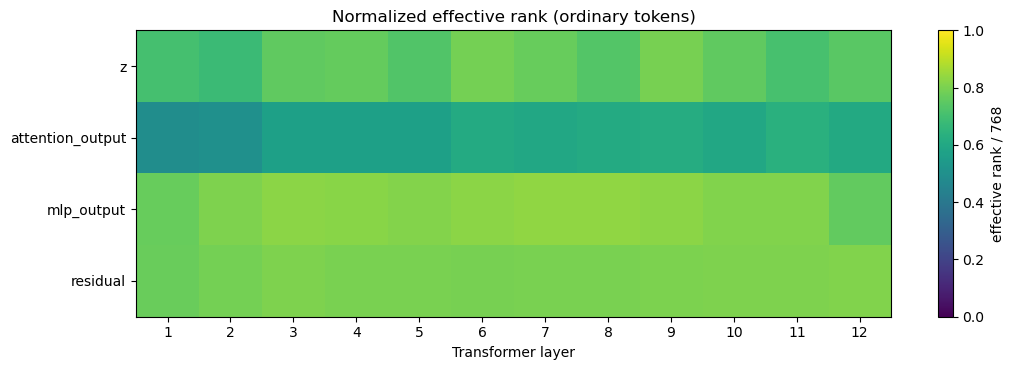

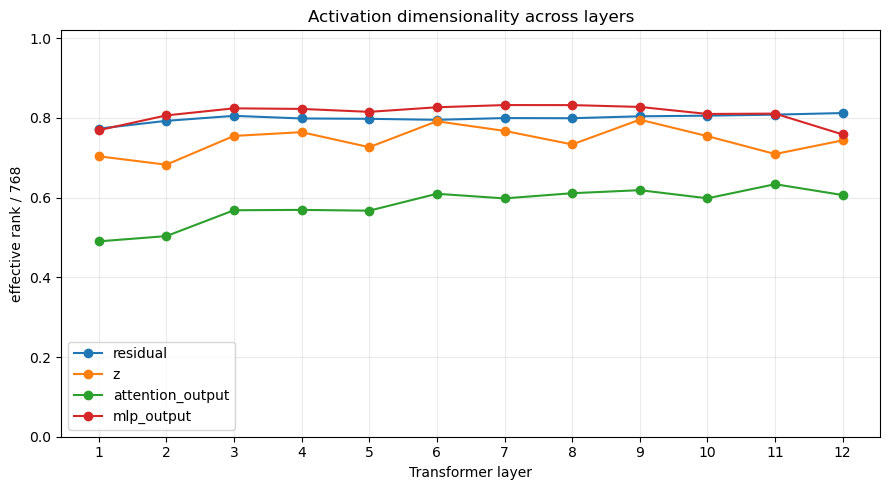

,layer,ratio_erank_o_to_z,ratio_erank_o_to_z_ci_lower,ratio_erank_o_to_z_ci_upper,ratio_erank_o_to_mlp,ratio_erank_o_to_mlp_ci_lower,ratio_erank_o_to_mlp_ci_upper,ratio_erank_o_to_residual,ratio_erank_o_to_residual_ci_lower,ratio_erank_o_to_residual_ci_upper,evidence
0,1,0.696739,0.696573,0.696889,0.637088,0.636671,0.637442,0.633762,0.633300,0.634163,clear_collapse
1,2,0.737574,0.737494,0.737650,0.624082,0.623943,0.624210,0.634853,0.634632,0.635059,clear_collapse
2,3,0.752953,0.752876,0.753019,0.689520,0.689409,0.689639,0.705694,0.705552,0.705830,clear_collapse
3,4,0.744842,0.744737,0.744954,0.691791,0.691685,0.691901,0.712575,0.712352,0.712811,clear_collapse
4,5,0.780788,0.780692,0.780883,0.695512,0.695304,0.695735,0.710785,0.710583,0.710981,clear_collapse
5,6,0.770149,0.770099,0.770197,0.737244,0.737175,0.737333,0.766442,0.766315,0.766573,clear_collapse
6,7,0.779284,0.779251,0.779320,0.718510,0.718300,0.718713,0.747865,0.747701,0.748023,clear_collapse
7,8,0.833102,0.833005,0.833186,0.734125,0.733950,0.734283,0.764416,0.764291,0.764548,clear_collapse
8,9,0.777680,0.777595,0.777772,0.747352,0.747216,0.747521,0.769243,0.769088,0.769429,clear_collapse
9,10,0.793312,0.793058,0.793553,0.738282,0.737574,0.738902,0.742259,0.741556,0.742888,clear_collapse


: 

In [ ]:
# 8. 图表、结论表与最终run manifest
completed_dir = finalize_activation_rank_run(config)
final_manifest = json.loads((completed_dir / 'manifest.json').read_text(encoding='utf-8'))
display(pd.Series(final_manifest))
display(plot_rank_heatmap(completed_dir / 'analysis'))
display(plot_rank_curves(completed_dir / 'analysis'))
display(pd.read_parquet(completed_dir / 'compression_metrics.parquet'))